In [2]:
import os
import pandas as pd
import ssl
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns   
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [3]:
import pandas as pd
print("\n=== [STAGE 2: DATA WRANGLING & CLEANING] ===")
df = pd.read_csv('raw_data/medical_appointments.csv')
print(f"Initial raw structural frame shape: {df.shape}")


=== [STAGE 2: DATA WRANGLING & CLEANING] ===
Initial raw structural frame shape: (110527, 14)


In [4]:
df = df.rename(columns={
    'Hipertension':'Hypertension',
    'Handcap':'Handicap',
    'No-show':'NoShow'
})

In [5]:
# 1. Direct Conversion inside the DataFrame
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], utc=True)
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], utc=True)

# 2. Extract the difference as a native Timedelta Series and pull out the integer days
df['LeadTimeDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

print("✔ SUCCESS! Dates parsed and LeadTimeDays calculated perfectly.")
print(df[['ScheduledDay', 'AppointmentDay', 'LeadTimeDays']].head())

✔ SUCCESS! Dates parsed and LeadTimeDays calculated perfectly.
               ScheduledDay            AppointmentDay  LeadTimeDays
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00            -1
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00            -1
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00            -1
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00            -1
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00            -1


In [6]:
df = df[(df['LeadTimeDays']>=0)& (df['Age'] >=0) & (df['Age']<=110)]

In [7]:
df['NoShow'] = df['NoShow'].map({'Yes':1, 'No':0})
df['Gender'] = df['Gender'].map({'F':1, 'M':0})

print(f"Cleaned dataset footprint: {df.shape[0]} valid patient vectors.")

Cleaned dataset footprint: 71955 valid patient vectors.


# machine learning pipeline

In [8]:
predictors = ['Gender', 'Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'LeadTimeDays']
X= df[predictors]
y = df['NoShow']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nTraining the Random Forest Classifier across patient vectors...")


Training the Random Forest Classifier across patient vectors...


In [10]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42,n_jobs=1)
clf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
from sklearn.metrics import accuracy_score
y_pred = clf.predict(X_test)
print(f"\n✔ Model Training Complete!")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


✔ Model Training Complete!
Overall Accuracy: 71.36%


In [12]:
from sklearn.metrics import classification_report
print("\n--- Detailed Clinical Classification Report ---")

print(classification_report(y_test,y_pred, target_names=['Showed up','No-show']))


--- Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

   Showed up       0.72      0.99      0.83     10287
     No-show       0.46      0.02      0.04      4104

    accuracy                           0.71     14391
   macro avg       0.59      0.51      0.44     14391
weighted avg       0.64      0.71      0.61     14391



In [13]:
importances = pd.DataFrame({
    'Clinical_Feature': predictors,
    'Importance_Score': clf.feature_importances_
}).sort_values(by='Importance_Score', ascending=False)

print("\n--- Root Drivers Behind Appointment Cancellations ---")
print(importances.to_string(index=False))


--- Root Drivers Behind Appointment Cancellations ---
Clinical_Feature  Importance_Score
             Age          0.464915
    LeadTimeDays          0.382813
    SMS_received          0.035033
    Hypertension          0.027999
          Gender          0.027069
     Scholarship          0.024237
      Alcoholism          0.020116
        Diabetes          0.017818


In [14]:
print("📊 Evaluating Optimized Machine Learning Pipeline...")
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:,1]

📊 Evaluating Optimized Machine Learning Pipeline...


In [16]:
from sklearn.metrics import roc_auc_score
print("\n=== Optimized Clinical Classification Report ===")

print(classification_report(y_test, y_pred, target_names=['Showed up','No-Show']))

print("--------------------------------------------------")
print(f"📊 Balanced Model ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")
print("--------------------------------------------------")


=== Optimized Clinical Classification Report ===
              precision    recall  f1-score   support

   Showed up       0.72      0.99      0.83     10287
     No-Show       0.46      0.02      0.04      4104

    accuracy                           0.71     14391
   macro avg       0.59      0.51      0.44     14391
weighted avg       0.64      0.71      0.61     14391

--------------------------------------------------
📊 Balanced Model ROC-AUC Score: 0.5942
--------------------------------------------------


In [17]:
importances = pd.DataFrame({
    'Clinical_features' : predictors,
    'Importance_Score': clf.feature_importances_
}).sort_values(by='Importance_Score', ascending=False)

C:\Users\MSI\AppData\Local\Temp\ipykernel_30464\918527344.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


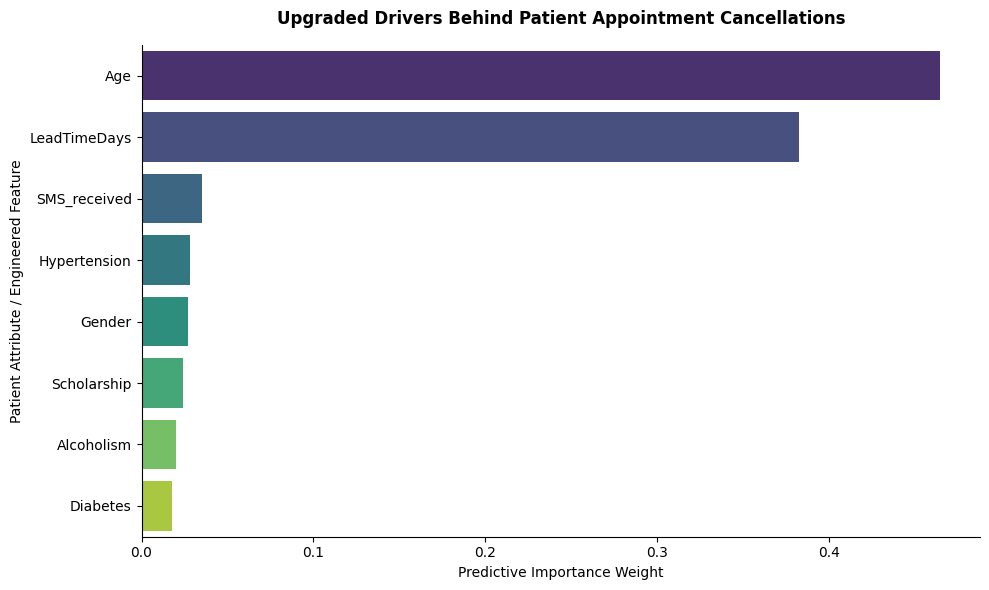

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(
    x ='Importance_Score',
    y ='Clinical_features',
    data= importances,
    palette='viridis'
)

plt.title('Upgraded Drivers Behind Patient Appointment Cancellations', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predictive Importance Weight')
plt.ylabel('Patient Attribute / Engineered Feature')
sns.despine()
plt.tight_layout()

In [20]:
plt.savefig('healthcare_feature_importance.png', dpi=300)
print("🎯 Visual asset saved successfully as 'healthcare_feature_importance.png'")
plt.show()

🎯 Visual asset saved successfully as 'healthcare_feature_importance.png'


<Figure size 640x480 with 0 Axes>